In [131]:
# *****IMPORT LABRARIES******

#Import pandas for working with the dataset
import  pandas as pd

# Import numpy for numerical operations
import numpy as np 

# Import matplotlib for creating visualisations
import  matplotlib.pyplot as plt

# Import seaborn for statistical visualisations
import seaborn as sns

# Import regular expressions for cleaning text
import re

# Import Natural Language Toolkit  for text preprocessing
import nltk


In [134]:
#*****DOWNLOAD K=NKLT RESOURCE*******

# Download the English stopword list from NLTK
nltk.download('stopwords')

# Download the tokenizer data required by NLTK
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dovha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dovha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [133]:
#******LAOD KAGGLE DATASET**********

# Load the Amazon Fine Food Reviews dataset
df = pd.read_csv("Reviews.csv")

# Display the first five rows
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [82]:
#Check the size of the dataset

print("Dataset shape:", df.shape)

Dataset shape: (568454, 10)


Amazon Fine Food Reviews data has around 568,454 Amazon customer reviews.
    
Product review reviews include information about product and customer, review rating and reviews text.
The number of observations is enough for text analysis and machine-learning modelling.

In [135]:
# Generate descriptive statistics for the numerical columns

# This helps us understand the distribution of variables such as Score and Id
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [83]:

#Display all column names in the dataset
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')


In [84]:

#Check the data types
# Display the data type of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [85]:
#Check for missing values
missing_values = df.isnull().sum()

# Display the missing values
print(missing_values)

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [86]:
#Remove missing review text

# Remove reviews where the review text is missing
df = df.dropna(subset=['Text'])

print ("Dataset shape removing  missing  text:",df.shape)

Dataset shape removing  missing  text: (568454, 10)


In [87]:
#Check for duplicates and remove the duplicates

# Check  duplicate rows
duplicates = df.duplicated().sum()

#remove the duplicates
df = df.drop_duplicates()


print ("Dataset shape after removing  duplicates:", df.shape)

Dataset shape after removing  duplicates: (568454, 10)


In [88]:
#Examine the customer rating.


# Count how many reviews have each rating
score_counts = df['Score'].value_counts().sort_index()

print(score_counts)

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


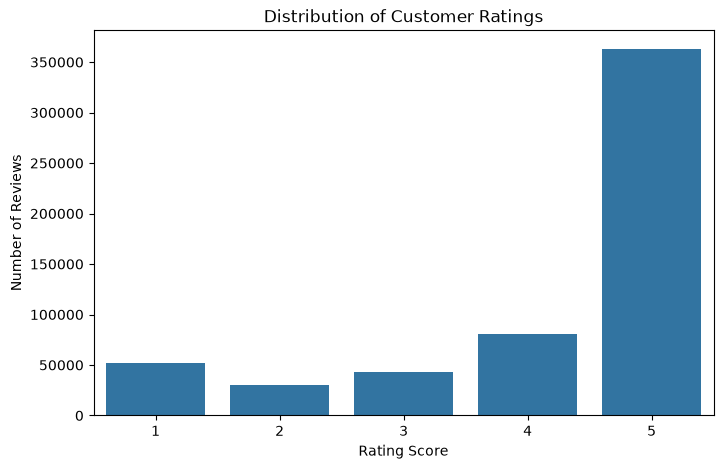

In [89]:
#****Visualisation, Plot rating  distribution*****

# Create a bar chart showing the distribution of customer ratings
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Score')

# Add a title and axis labels
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating Score')
plt.ylabel('Number of Reviews')


plt.show()

The rating breakdown reveals that the five rating levels do not apply consistently across consumer reviews.

The most often used grades were 35000.

This shows that the dataset has to be taken into account as the 
sentiment classification model is developed as it is unbalanced between
favorable and negative reviews.

In [90]:
#****Create sentiment labels****

# Create a function to convert the numerical rating into sentiment
def create_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score >= 4:
        return 'Positive'
    else:
        return 'Neutral'
# Apply the sentiment function to the Score column
df['Sentiment'] = df['Score'].apply(create_sentiment)

# Display the first five rows
df[['Score', 'Sentiment', 'Text']].head()

,Score,Sentiment,Text
0,5,Positive,I have bought several of the Vitality canned d...
1,1,Negative,Product arrived labeled as Jumbo Salted Peanut...
2,4,Positive,This is a confection that has been around a fe...
3,2,Negative,If you are looking for the secret ingredient i...
4,5,Positive,Great taffy at a great price. There was a wid...


In [91]:
#****Remove neutral reviews***

#Keep only positive and negative reviews
df_sentiment = df[df['Sentiment'] != 'Neutral'].copy()


# Display the number of positive and negative reviews
print(df_sentiment['Sentiment'].value_counts())

Sentiment
Positive    443777
Negative     82037
Name: count, dtype: int64


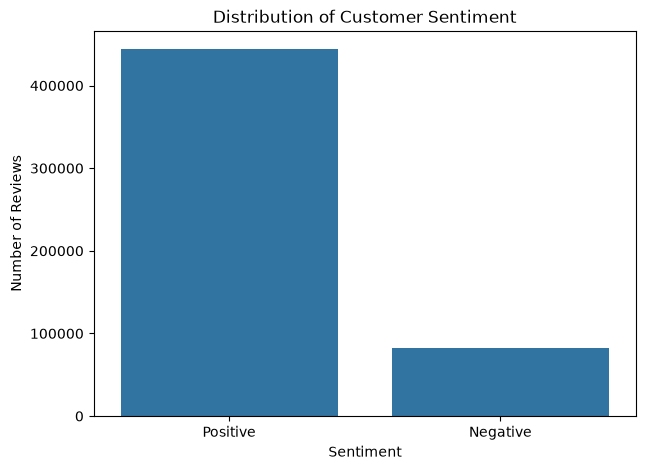

In [92]:
#Visualise sentiment distribution

# Create a bar chart showing positive and negative reviews
plt.figure(figsize=(7, 5))
sns.countplot(data=df_sentiment, x='Sentiment')

# Add title and labels
plt.title('Distribution of Customer Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

# Display the chart
plt.show()

In [93]:
#****IMPORT TEXT-PROCESSING TOOLS

# Import the regular expression library
import re

# Import English stopwords
from nltk.corpus import stopwords

# Create a list of English stopwords
stop_words = set(stopwords.words('english'))

# Create a function to clean each review

#Convert  text to  lowercase
#Remove HTML tags
#Remove Punctuation
#remove extra space
def clean_text(text):
    text = text.lower()                         
    text = re.sub(r'<.*?>', ' ', text)          
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   
    text = re.sub(r'\s+', ' ', text).strip()  
    
    # Split the text into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Put the words back together
    return ' '.join(words)

In [94]:
#Apply a text  cleaning

# Apply the cleaning function to the review text
df_sentiment['Clean_Text'] = df_sentiment['Text'].apply(clean_text)

# Display the original and cleaned text
df_sentiment[['Text', 'Clean_Text']].head()

,Text,Clean_Text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanuts p...
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [95]:
#*****Calculate Review Lenght*****

# Calculate the number of words in each cleaned review
df_sentiment['Review_Length'] = df_sentiment['Clean_Text'].apply(
    lambda x: len(x.split())
)

# Display basic statistics about review length
print(df_sentiment['Review_Length'].describe())

count    525814.000000
mean         38.973158
std          39.559461
min           0.000000
25%          16.000000
50%          27.000000
75%          47.000000
max        1564.000000
Name: Review_Length, dtype: float64


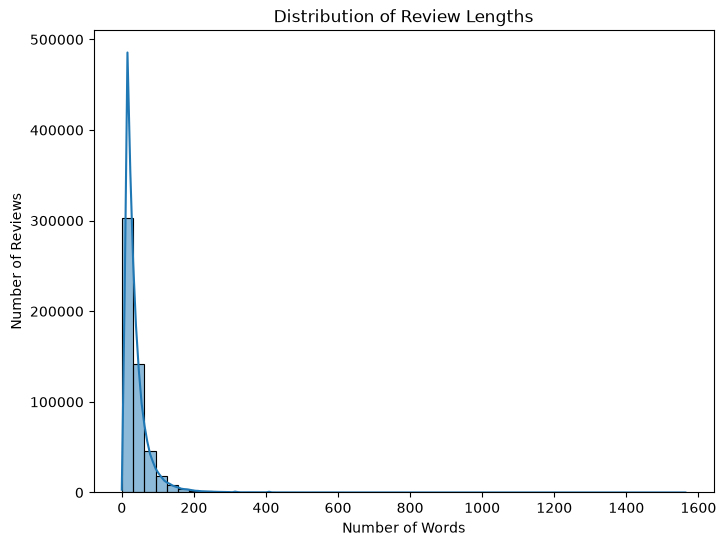

In [96]:
#****Plot Sentiment Distibution****


# Create a histogram showing the distribution of review lengths
plt.figure(figsize=(8, 6))

sns.histplot(
    df_sentiment['Review_Length'],
    bins=50,
    kde=True
)

# Add title and labels
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

# Display the graph
plt.show()

Find the most frequent words

In [97]:
#****Count  word frequencies*****


# Import Counter to count words efficiently
from collections import Counter

# Create an empty counter
word_frequency = Counter()

# Go through each cleaned review
for review in df_sentiment['Clean_Text']:
    
    # Make sure the review is treated as text
    review = str(review)
    
    # Split the review into individual words
    words = review.split()
    
    # Add the words to our counter
    word_frequency.update(words)

# Display the 50 most common words
print(word_frequency.most_common(50))

[('like', 229727), ('good', 181894), ('one', 162060), ('great', 159548), ('taste', 153101), ('coffee', 148659), ('product', 137404), ('flavor', 131368), ('tea', 127566), ('love', 121310), ('food', 119745), ('would', 108746), ('get', 98782), ('really', 91107), ('amazon', 85253), ('much', 82820), ('also', 80161), ('time', 77986), ('use', 77289), ('little', 75434), ('best', 73679), ('tried', 71119), ('buy', 70274), ('price', 69781), ('even', 69427), ('find', 68693), ('well', 67801), ('make', 66412), ('dog', 64054), ('try', 62738), ('better', 62633), ('eat', 62208), ('cup', 56794), ('first', 55955), ('chocolate', 55736), ('water', 54246), ('bag', 53274), ('sugar', 52067), ('found', 50054), ('used', 49729), ('free', 47848), ('sweet', 47564), ('made', 47202), ('day', 46228), ('drink', 46024), ('bought', 45919), ('box', 45089), ('way', 45039), ('two', 44857), ('store', 43069)]


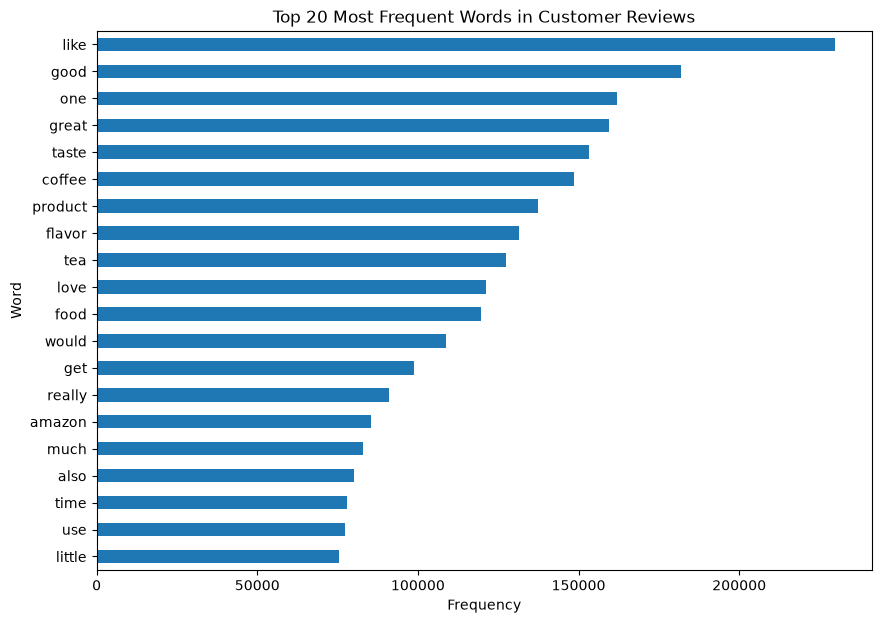

In [98]:

#****Plot  Top 20 Words****

# Get the 20 most frequent words
top_words = word_frequency.most_common(20)

# Convert the results into a pandas Series for plotting
top_words_series = pd.Series(
    dict(top_words)
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 7))

top_words_series.sort_values().plot(kind='barh')

# Add title and labels
plt.title('Top 20 Most Frequent Words in Customer Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

# Display the chart

plt.show()

In [99]:
#******Create A word Cload*****

# Install the WordCloud library
!pip install wordcloud

In [114]:
# Import the WordCloud library
from wordcloud import WordCloud

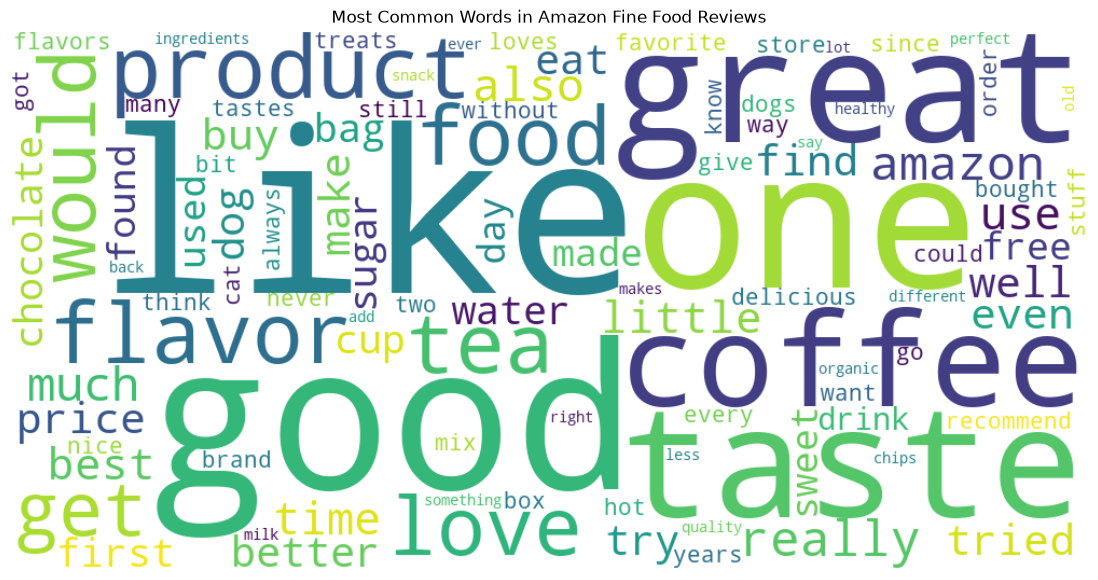

In [115]:
# Create a word cloud from the most frequent words

# Convert the word frequencies into a dictionary
wordcloud_data = dict(word_frequency.most_common(100))

# Create the word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate_from_frequencies(wordcloud_data)

# Display the word cloud
plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation='bilinear')

# Hide the axes
plt.axis('off')

# Add a title
plt.title('Most Common Words in Amazon Fine Food Reviews')

# Display the word cloud
plt.show()

In [102]:
#******Feature Engineering ****

In [117]:
#Create modelling sample
model_data = df_sentiment.sample(
    n=50000,
    random_state=42
).copy()

In [113]:
# ============================================
# STEP 28: CREATE X AND Y
# ============================================

# Use the 50,000-review modelling sample
X = model_data['Clean_Text']

# Use sentiment as the target variable
y = model_data['Sentiment']

# Display the first five reviews
print("Sample cleaned reviews:")
print(X.head())

# Display the first five sentiment labels
print("\nSample sentiment labels:")
print(y.head())

# Display the number of reviews used
print("\nTotal reviews used for modelling:", len(model_data))

Sample cleaned reviews:
443593    high quality dog food meat fruits grains dog l...
136949    love cake mix mixes well incredible amazon off...
520459    nice strong brew new keurig lived french press...
219515    found pb pb chocolate thrilled love sugary goo...
471273    delightful mint tea one would expect note tea ...
Name: Clean_Text, dtype: str

Sample sentiment labels:
443593    Positive
136949    Positive
520459    Positive
219515    Positive
471273    Positive
Name: Sentiment, dtype: str

Total reviews used for modelling: 50000


In [105]:
# *******TRAIN-TEST SPLIT**************

from sklearn.model_selection import train_test_split

# Split the 50,000-review sample into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of observations
print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 40000
Testing reviews: 10000


In [106]:

# ***FEATURE ENGINEERING USING TF-IDF***-TF-IDF vectorisation


# Import the train-test split function
from sklearn.model_selection import train_test_split

# Import the TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Use a smaller sample for machine learning
# This reduces memory usage on the computer
model_data = df_sentiment.sample(
    n=50000,
    random_state=42
).copy()

# Separate the review text from the sentiment label
X = model_data['Clean_Text']
y = model_data['Sentiment']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Learn the vocabulary from the training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the testing data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Display the results
print("\nTF-IDF FEATURE ENGINEERING COMPLETED")
print("------------------------------------")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

# Display the first 20 TF-IDF features
print("\nFirst 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])

Training reviews: 40000
Testing reviews: 10000

TF-IDF FEATURE ENGINEERING COMPLETED
------------------------------------
Training TF-IDF shape: (40000, 5000)
Testing TF-IDF shape: (10000, 5000)
Number of features: 5000

First 20 TF-IDF features:
['ability' 'able' 'able buy' 'able find' 'able get' 'absolute'
 'absolute favorite' 'absolutely' 'absolutely delicious' 'absolutely love'
 'absolutely loves' 'acai' 'accept' 'acceptable' 'access' 'accident'
 'according' 'account' 'acid' 'acidic']


In [107]:

# *****TRAIN LOGISTIC REGRESSION MODEL******

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logreg = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train the model using the TF-IDF training data
logreg.fit(X_train_tfidf, y_train)

# Display confirmation
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [108]:

#******MAKE SENTIMENT PREDICTIONS*****

# Predict the sentiment of the test reviews
y_pred = logreg.predict(X_test_tfidf)

# Display the first 20 predictions
print("First 20 predictions:")

print(y_pred[:20])

First 20 predictions:
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative']


In [109]:

#  EVALUATE THE MODEL

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
precision = precision_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

# Calculate recall
recall = recall_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

# Calculate F1-score
f1 = f1_score(
    y_test,
    y_pred,
    pos_label='Positive'
)

# Display the results
print("MODEL PERFORMANCE")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

MODEL PERFORMANCE
-----------------
Accuracy : 0.9157
Precision: 0.9207
Recall   : 0.9848
F1-score : 0.9517


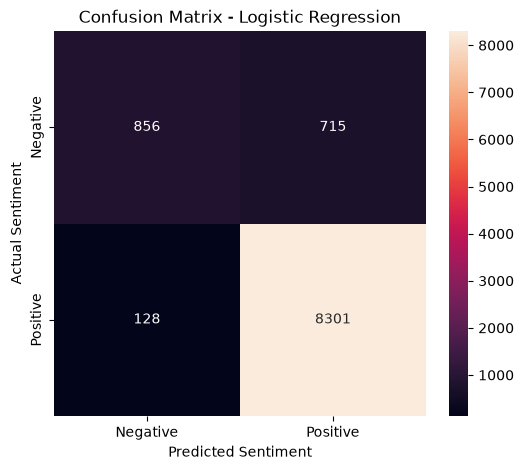

In [110]:

# ******CONFUSION MATRIX*************


from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Negative', 'Positive']
)

# Display the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

# Close the figure to release memory
plt.close()

In [119]:
#LDA Topic Modelling

# ============================================
# STEP 35: PREPARE DATA FOR TOPIC MODELLING
# ============================================

from sklearn.feature_extraction.text import CountVectorizer

# Select a smaller sample for topic modelling
topic_data = df_sentiment.sample(
    n=10000,
    random_state=42
).copy()

# Create the Bag-of-Words vectorizer
count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.95
)

# Convert reviews into a document-term matrix
X_topics = count_vectorizer.fit_transform(
    topic_data['Clean_Text']
)

# Display the result
print("Topic modelling data shape:", X_topics.shape)
print("Number of vocabulary terms:", len(count_vectorizer.get_feature_names_out()))

Topic modelling data shape: (10000, 3000)
Number of vocabulary terms: 3000


In [124]:
# ******* DISPLAY TOP WORDS FOR EACH TOPIC********8*

# Get all vocabulary words
feature_names = count_vectorizer.get_feature_names_out()

# Display the 10 most important words in each topic
for topic_number, topic in enumerate(lda.components_):
    
    # Get the indexes of the most important words
    top_word_indexes = topic.argsort()[-10:][::-1]
    
    # Get the actual words
    top_words = [
        feature_names[index]
        for index in top_word_indexes
    ]
    
    # Display the topic
    print(f"Topic {topic_number + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
coffee, cup, like, flavor, good, one, taste, cups, great, love

Topic 2:
tea, taste, good, like, flavor, product, great, drink, green, use

Topic 3:
food, dog, one, dogs, cat, treats, like, loves, eat, would

Topic 4:
like, good, taste, great, flavor, chocolate, love, one, eat, snack

Topic 5:
amazon, product, like, find, get, great, one, price, time, good



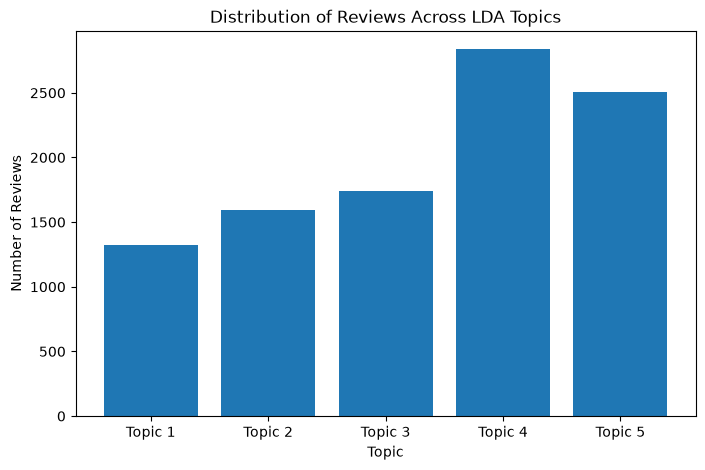

In [126]:

# **********TOPIC DISTRIBUTION**********

# Assign each review to its strongest topic
topic_assignments = lda.transform(X_topics).argmax(axis=1)

# Count the number of reviews assigned to each topic
topic_counts = pd.Series(topic_assignments).value_counts().sort_index()

# Create topic names
topic_names = [
    f"Topic {i + 1}"
    for i in range(len(topic_counts))
]

# Create the bar chart
plt.figure(figsize=(8, 5))

plt.bar(topic_names, topic_counts.values)

plt.title('Distribution of Reviews Across LDA Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')

plt.show()

plt.close()

In [127]:
# ***********CLASSIFICATION REPORT**************

from sklearn.metrics import classification_report

# Generate a detailed classification report
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

    Negative       0.87      0.54      0.67      1571
    Positive       0.92      0.98      0.95      8429

    accuracy                           0.92     10000
   macro avg       0.90      0.76      0.81     10000
weighted avg       0.91      0.92      0.91     10000



In [128]:
# **********IMPROVED LOGISTIC REGRESSION**********


# Create an improved Logistic Regression model
logreg_improved = LogisticRegression(
    C=2.0,
    max_iter=1000,
    random_state=42
)

# Train the improved model
logreg_improved.fit(
    X_train_tfidf,
    y_train
)

# Make predictions
y_pred_improved = logreg_improved.predict(
    X_test_tfidf
)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [129]:
# ************** EVALUATE IMPROVED MODEL*************

# Calculate improved model metrics
accuracy_improved = accuracy_score(
    y_test,
    y_pred_improved
)

precision_improved = precision_score(
    y_test,
    y_pred_improved,
    pos_label='Positive'
)

recall_improved = recall_score(
    y_test,
    y_pred_improved,
    pos_label='Positive'
)

f1_improved = f1_score(
    y_test,
    y_pred_improved,
    pos_label='Positive'
)

# Display results
print("IMPROVED MODEL PERFORMANCE")
print("--------------------------")
print(f"Accuracy : {accuracy_improved:.4f}")
print(f"Precision: {precision_improved:.4f}")
print(f"Recall   : {recall_improved:.4f}")
print(f"F1-score : {f1_improved:.4f}")

IMPROVED MODEL PERFORMANCE
--------------------------
Accuracy : 0.9204
Precision: 0.9299
Recall   : 0.9794
F1-score : 0.9540


In [130]:

********** MODEL COMPARISON*********

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ],
    
    'Original Logistic Regression': [
        accuracy,
        precision,
        recall,
        f1
    ],
    
    'Improved Logistic Regression': [
        accuracy_improved,
        precision_improved,
        recall_improved,
        f1_improved
    ]
})

# Display the comparison
comparison

,Metric,Original Logistic Regression,Improved Logistic Regression
0,Accuracy,0.915700,0.920400
1,Precision,0.920697,0.929931
2,Recall,0.984814,0.979357
3,F1-score,0.951677,0.954004
